In [4]:
import json
from pathlib import Path

from model_ranking import (
    plot_performance_vs_transfer_metric_multi_target,
    to_target_transfer_correlations,
    correlation_table,
    load_transfer_metric_results,
)

# MAP Performance vs ARE consis (Fullslice)

In [5]:
performance_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/finetuned_fullslice/transfer_performance_MAP_scores.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]

Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/finetuned_fullslice/transfer_self_supervised_Gauss_a001-005_FORG_ARE_scores.json
Processing: Gauss_Consistency_a001-005
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


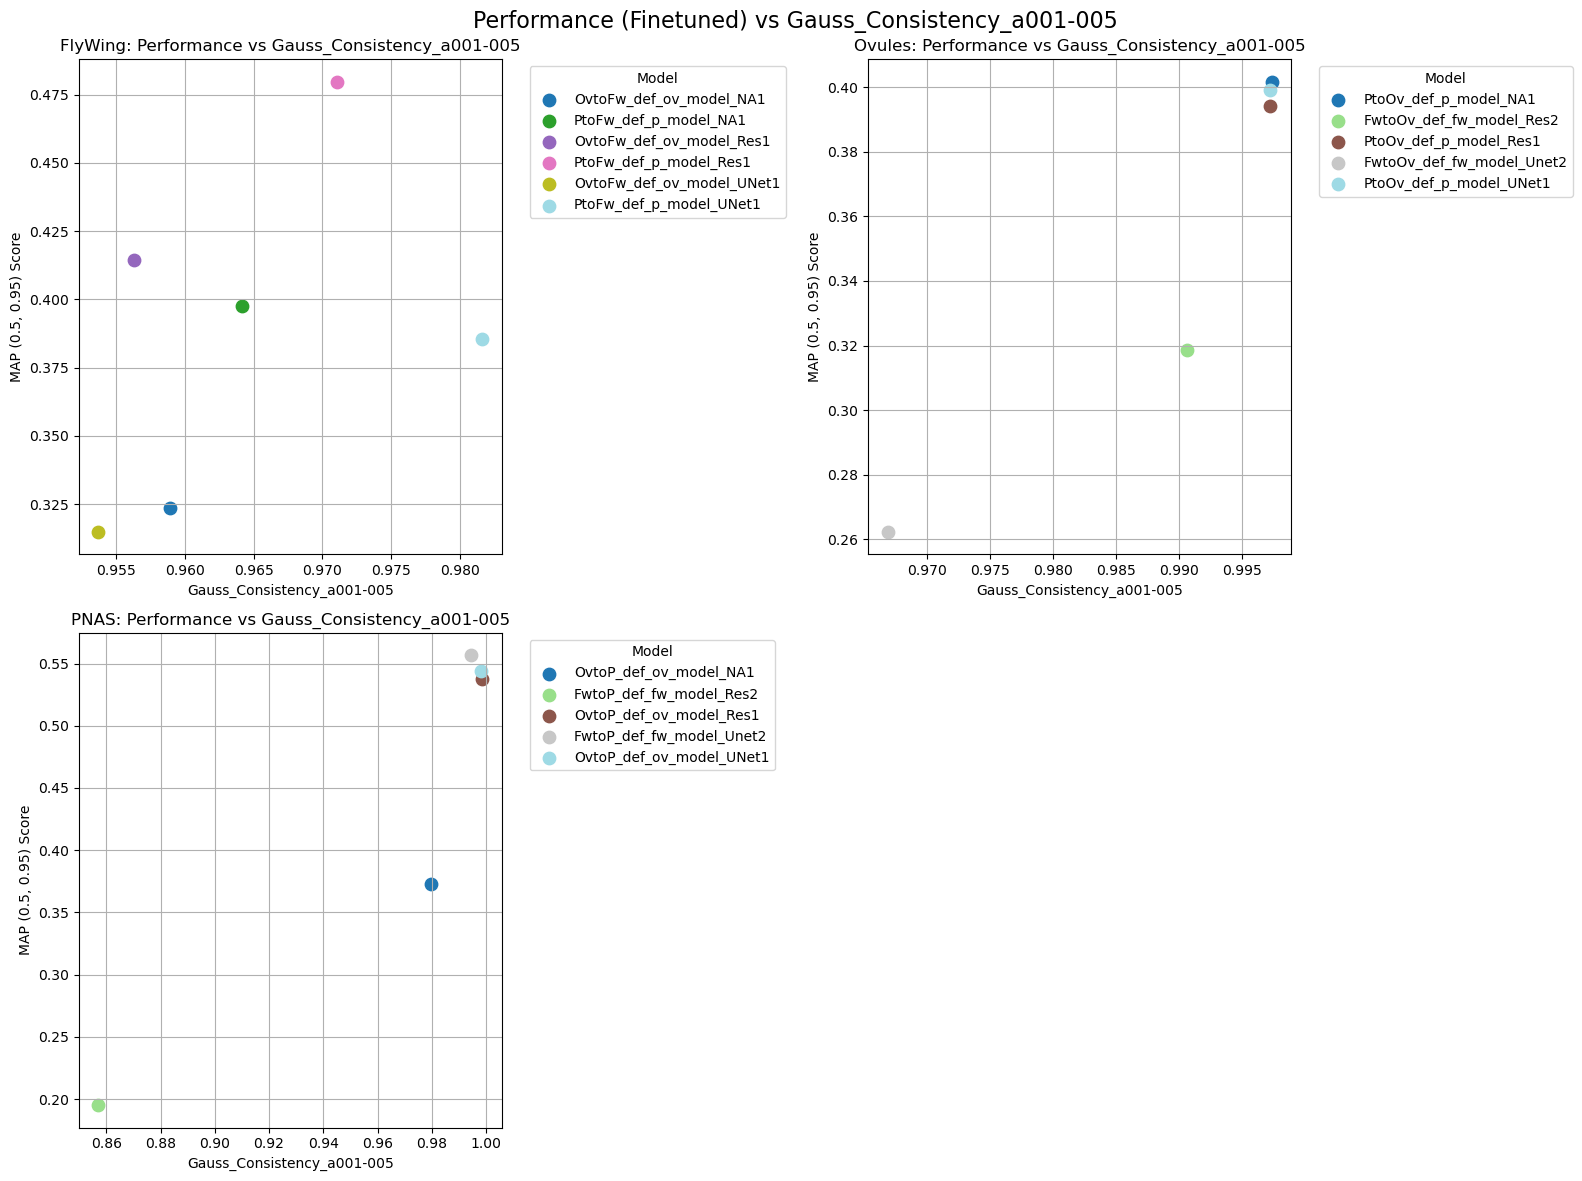

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.33     0.48   0.43        0.35  0.46     0.36
     Ovules   0.80     0.10   0.90        0.08  0.93     0.02
     PNAS     0.40     0.51   0.60        0.35  0.93     0.02
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/finetuned_fullslice/transfer_self_supervised_Gauss_a005-01_FORG_ARE_scores.json
Processing: Gauss_Consistency_a005-01
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


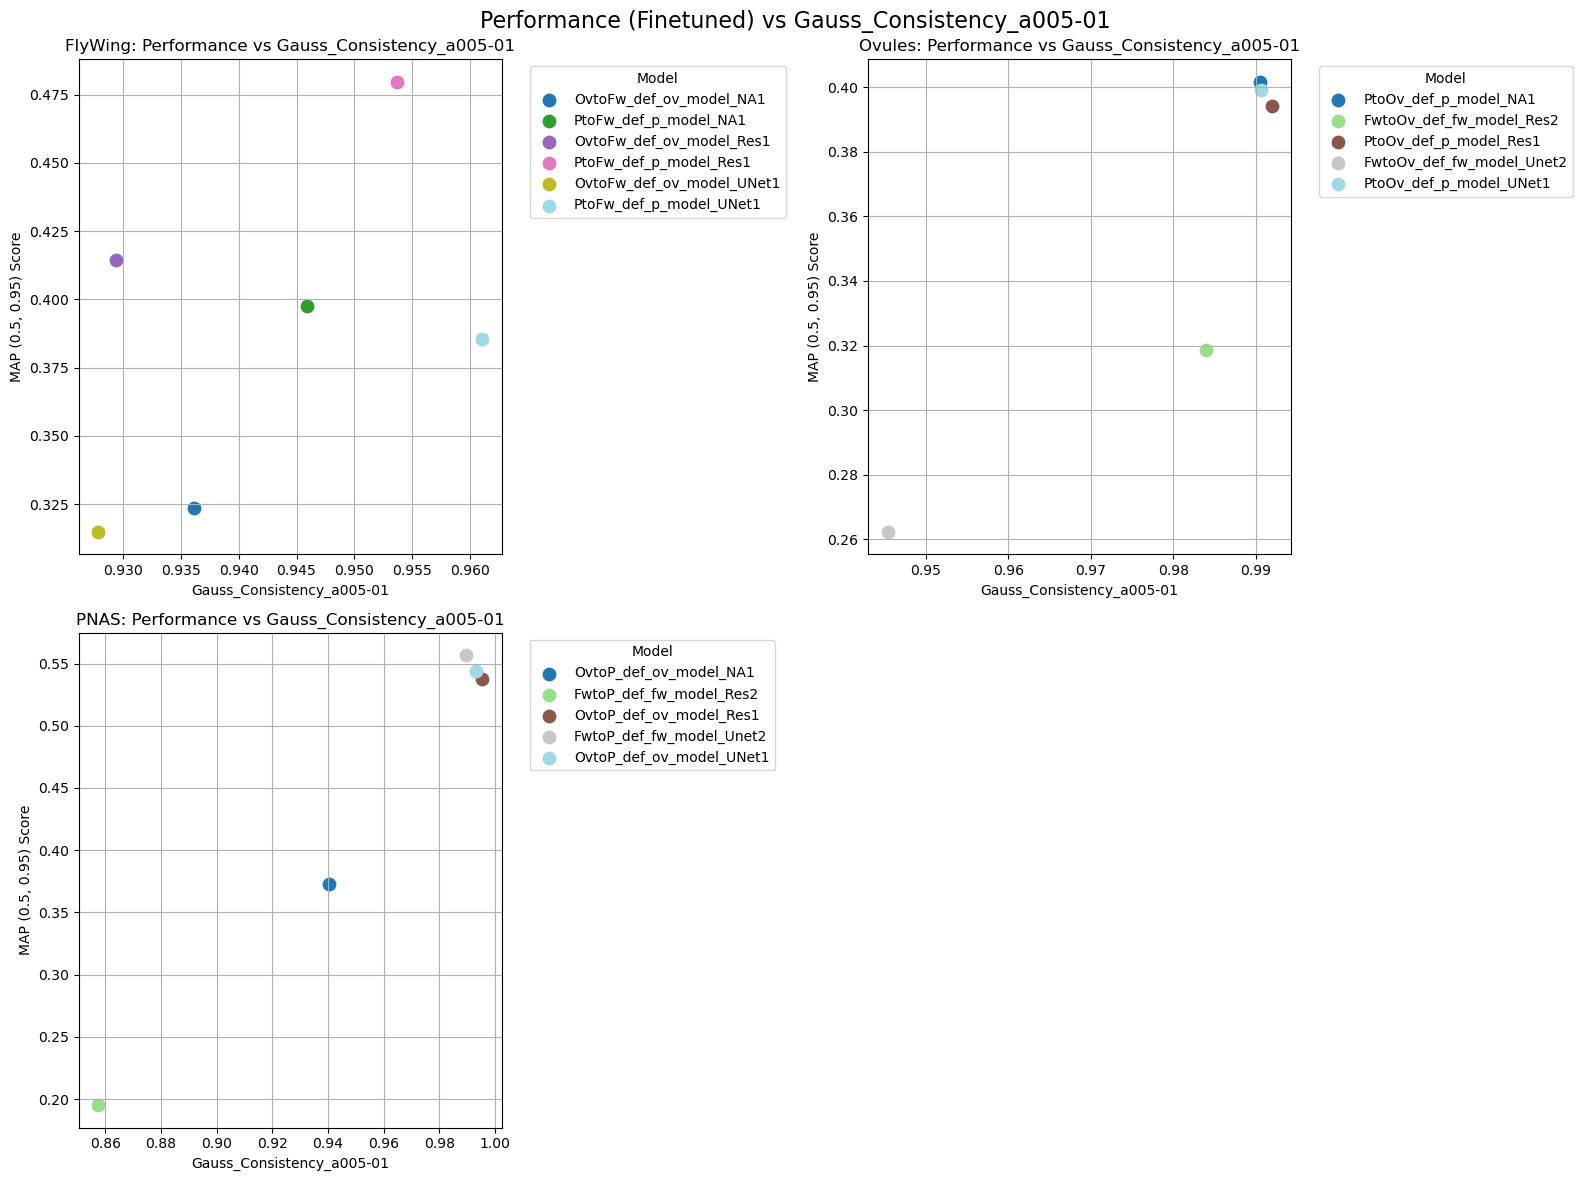

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.33     0.44   0.43        0.44  0.52     0.29
     Ovules   0.40     0.51   0.60        0.38  0.91     0.03
     PNAS     0.40     0.41   0.60        0.32  0.99     0.00
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/finetuned_fullslice/transfer_self_supervised_Gauss_a01-015_FORG_ARE_scores.json
Processing: Gauss_Consistency_a01-015
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


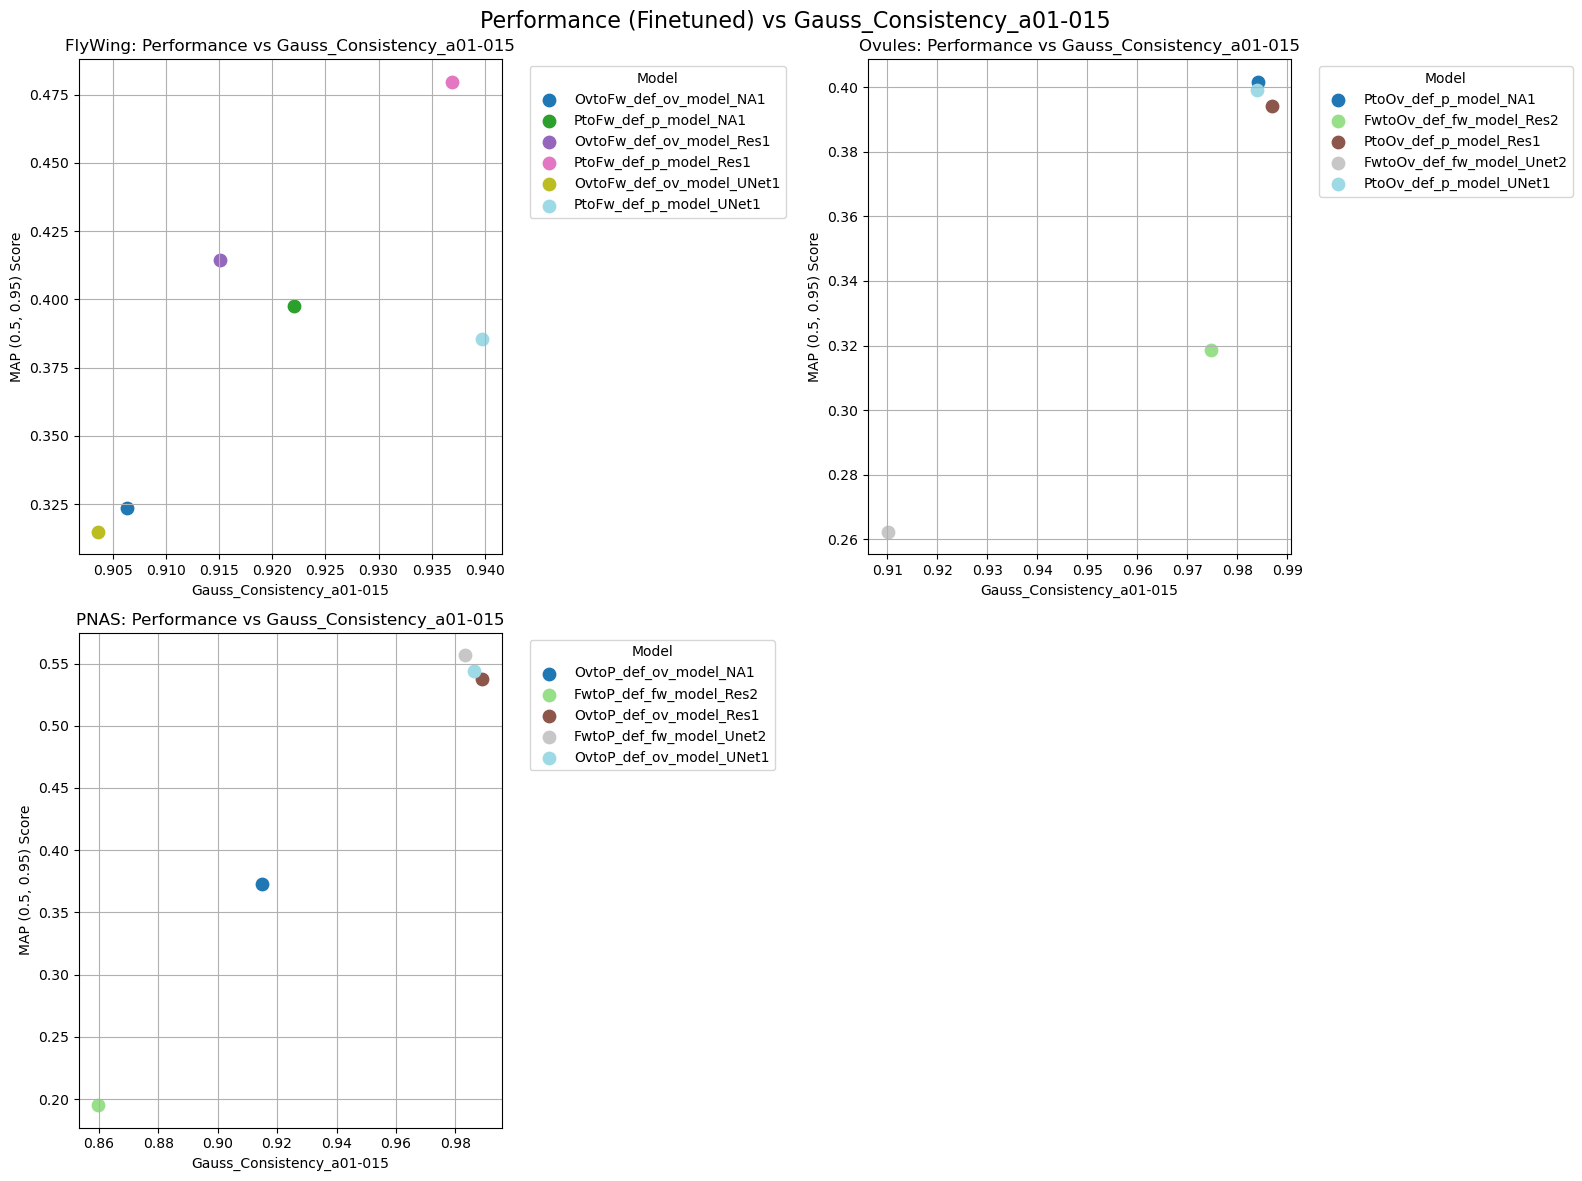

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.47     0.26    0.6        0.26  0.75     0.09
     Ovules   0.60     0.25    0.7        0.24  0.90     0.04
     PNAS     0.40     0.44    0.6        0.35  0.99     0.00
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/finetuned_fullslice/transfer_self_supervised_Gauss_a015-02_FORG_ARE_scores.json
Processing: Gauss_Consistency_a015-02
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


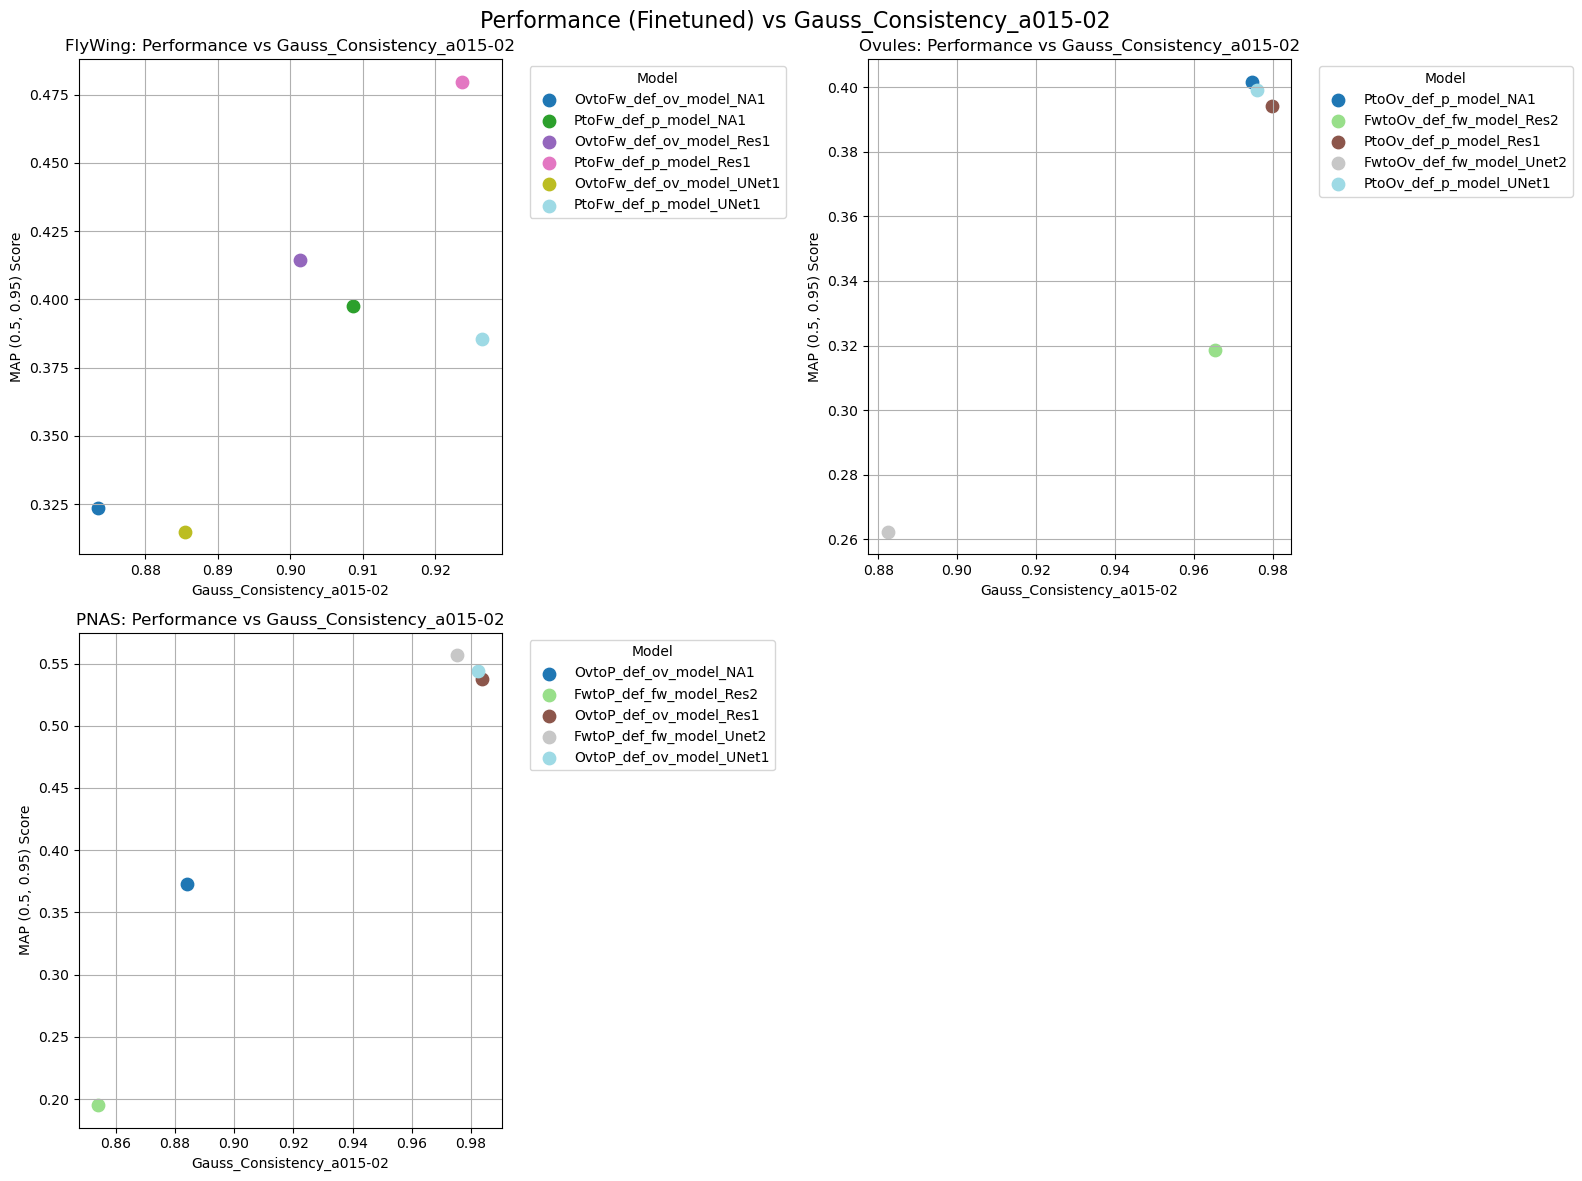

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.33     0.49   0.54        0.30  0.79     0.06
     Ovules   0.40     0.48   0.60        0.33  0.89     0.04
     PNAS     0.40     0.49   0.60        0.36  0.97     0.01
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/finetuned_fullslice/transfer_self_supervised_Gauss_a02-025_FORG_ARE_scores.json
Processing: Gauss_Consistency_a02-025
Number of targets: 3
  Target 1: FlyWing
  Target 2: Ovules
  Target 3: PNAS


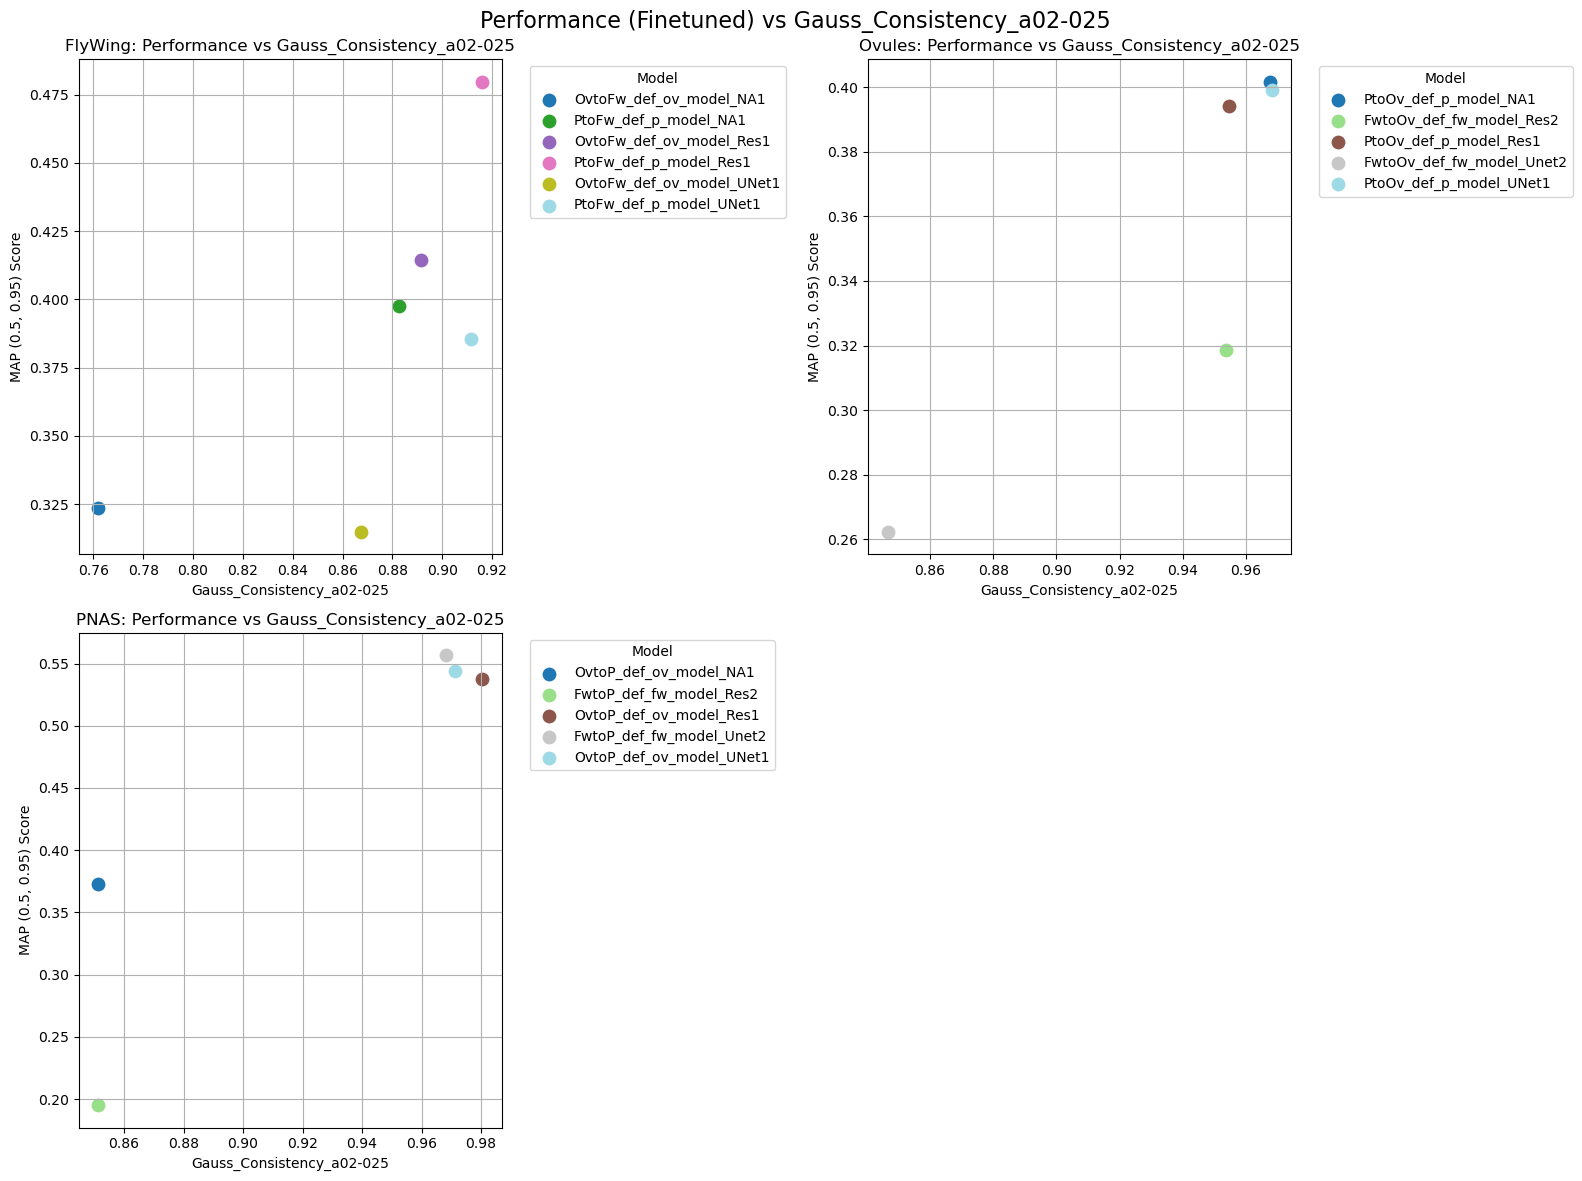

               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito FlyWing  0.6     0.12   0.77        0.12  0.69     0.13
     Ovules   0.8     0.08   0.90        0.08  0.87     0.05
     PNAS     0.4     0.49   0.60        0.34  0.91     0.03


In [6]:
base_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/finetuned_fullslice"
selected_augmentations = ["a001-005", "a005-01", "a01-015", "a015-02", "a02-025"]

correlation_dfs = []

for aug in selected_augmentations:
    file_name = f"transfer_self_supervised_Gauss_{aug}_FORG_ARE_scores.json"
    consistency_path = Path(base_path) / file_name
    results = load_transfer_metric_results(consistency_path)
    consistency_scores = results["transfer_scores"]
    targets = list(consistency_scores.keys())
    plot_performance_vs_transfer_metric_multi_target(
        performance_scores=performance_scores,
            transfer_scores=consistency_scores,
            transfer_metric=f"Gauss_Consistency_{aug}",
            invert_transfer_metric=True,
            finetuned=True,
            performance_metric_key="MAP (0.5, 0.95)",
        )
    KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
        targets=targets,
        transfer_metric_per_target=consistency_scores,
        performance_per_target=performance_scores,
        invert_transfer_metric=True,
    )
    correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
    correlation_dfs.append(correlation_df)
    print(correlation_df)
            
        

In [7]:
for aug_str, df in zip(selected_augmentations, correlation_dfs):
    print(f"Augmentation: {aug_str}")
    print(df)

Augmentation: a001-005
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.33     0.48   0.43        0.35  0.46     0.36
     Ovules   0.80     0.10   0.90        0.08  0.93     0.02
     PNAS     0.40     0.51   0.60        0.35  0.93     0.02
Augmentation: a005-01
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.33     0.44   0.43        0.44  0.52     0.29
     Ovules   0.40     0.51   0.60        0.38  0.91     0.03
     PNAS     0.40     0.41   0.60        0.32  0.99     0.00
Augmentation: a01-015
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.47     0.26    0.6        0.26  0.75     0.09
     Ovules   0.60     0.25    0.7        0.24  0.90     0.04
     PNAS     0.40     0.44    0.6        0.35  0.99     0.00
Aug